# Major Project: Seasonal Agriculture Performance Analysis

This project is based on an agricultural dataset containing information about different seasons, crops, geographical areas, environmental conditions, farming practices, resource usage and economic performance.

The main purpose of this project is to understand how agricultural performance changes across seasons and to identify useful patterns and relationships from the data.

## Problem Statement

Agricultural performance can vary from one season to another due to factors such as rainfall, temperature, soil conditions, irrigation, crop type and resource usage.

In this project, I will analyze the given agricultural dataset to compare performance across seasons and identify important patterns, trends, relationships and variations in the data.

## Objectives

- Understand the given agricultural dataset.
- Clean and prepare the data for analysis.
- Examine agricultural performance across different seasons.
- Identify seasonal patterns and trends.
- Study environmental conditions and their relationship with agricultural outcomes.
- Compare resource usage across seasons.
- Compare crops, states and irrigation methods.
- Analyze economic performance such as cost, revenue and profit.
- Identify unusual patterns and variations in the dataset.
- Apply suitable statistical and visualization techniques.
- Interpret the results and provide data-based conclusions and recommendations.

## 1. Importing Required Libraries

I am importing the libraries required for data cleaning, analysis, visualization and statistical testing.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal

pd.set_option('display.max_columns', None)

## 2. Uploading the Dataset

I am uploading the given CSV file directly into Google Colab.

In [5]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv


## 3. Loading the Dataset

The uploaded CSV file is loaded into a Pandas DataFrame named `df`.

In [7]:
file_name = next(iter(uploaded))

df = pd.read_csv(file_name)

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 4. Dataset Size

I am checking the number of records and variables available in the dataset.

In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 4000
Columns: 28


## 5. Basic Information

I am checking the structure of the dataset and the data types of its columns.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

## 6. Column Names

The dataset contains different variables related to seasons, crops, locations, environmental conditions, resources and agricultural performance.

In [10]:
df.columns.tolist()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

## 7. Initial Data Exploration

I am viewing some records to understand the type of information present in the dataset.

In [11]:
df.head(10)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3
5,SF10006,Gujarat,Raichur,Pulses,Zaid,5.46,356.0,33.6,49.0,8.3,6.93,11.4,105.1,34.7,78.7,Rainfed,58.8,4.48,0.89,0.72,3.93,68593,302333,269570,-32763,1093,3.596,57.1
6,SF10007,Telangana,Warangal,Wheat,Rabi,8.13,432.2,23.5,50.8,9.5,6.96,24.7,115.8,69.4,109.8,Rainfed,181.6,7.99,0.87,2.53,20.57,22951,513341,472102,-41239,2368,8.687,31.6
7,SF10008,Tamil Nadu,Ludhiana,Pulses,Kharif,5.34,860.2,29.0,64.9,7.9,6.09,36.9,112.7,60.9,115.9,Sprinkler,245.8,5.89,0.70,1.18,6.30,70042,436200,441265,5065,1704,3.697,54.2
8,SF10009,Karnataka,Guntur,Cotton,Zaid,6.98,624.7,33.4,46.8,7.9,6.41,12.3,66.9,47.6,134.2,Sprinkler,190.7,2.21,0.88,1.53,10.68,70771,525129,755834,230705,5079,2.103,54.7
9,SF10010,Tamil Nadu,Raichur,Chilli,Rabi,13.69,415.8,22.3,57.3,8.6,6.60,23.3,117.9,37.2,116.6,Drip,168.8,7.29,0.70,2.29,31.35,94383,1004072,2958907,1954835,5984,5.239,41.7


## 8. Descriptive Statistics

I am using descriptive statistics to understand the numerical variables in the dataset.

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


## 9. Categorical Variables

I am checking the unique values of important categorical variables such as season, crop, state and irrigation method.

In [13]:
print("Seasons:")
print(df['Season'].unique())

print("\nCrops:")
print(df['Crop'].unique())

print("\nStates:")
print(df['State'].unique())

print("\nIrrigation Methods:")
print(df['Irrigation_Method'].unique())

Seasons:
['Kharif' 'Rabi' 'Zaid']

Crops:
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

States:
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

Irrigation Methods:
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


## 10. Missing Value Analysis

Before starting the main analysis, I am checking the dataset for missing values.

In [14]:
missing = df.isnull().sum()

missing[missing > 0]

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


## 11. Missing Value Percentage

I am calculating the percentage of missing values in the dataset.

In [15]:
missing_table = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_table[missing_table['Missing Values'] > 0]

,Missing Values,Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


## 12. Duplicate Records

I am checking whether any complete duplicate records are present in the dataset.

In [16]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 13. Data Cleaning and Preparation

I am creating a separate cleaned DataFrame so that the original dataset remains unchanged.

Missing rainfall and soil moisture values are filled using the median value of the corresponding crop and season group.

Missing yield values are not artificially filled because yield is an important outcome variable. These records will be excluded only from analyses where yield is required.

In [17]:
df_clean = df.copy()

df_clean = df_clean.drop_duplicates().copy()

for column in ['Rainfall_mm', 'Soil_Moisture_pct']:
    df_clean[column] = df_clean.groupby(
        ['Crop', 'Season']
    )[column].transform(
        lambda x: x.fillna(x.median())
    )

for column in ['Rainfall_mm', 'Soil_Moisture_pct']:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

print("Data cleaning completed.")

Data cleaning completed.


## 14. Verification After Cleaning

I am checking the missing values and duplicate records again after data cleaning.

In [18]:
print("Missing values:")
display(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

print("\nDuplicate rows:", df_clean.duplicated().sum())

Missing values:


,0
Yield_Tonnes_Ha,32



Duplicate rows: 0


## 15. Preparing Data for Yield Analysis

Yield is one of the main performance measures in this project. I am creating a separate DataFrame containing records where yield is available.

In [19]:
df_yield = df_clean.dropna(subset=['Yield_Tonnes_Ha']).copy()

print("Records available for yield analysis:", len(df_yield))

Records available for yield analysis: 3968


## 16. Distribution of Records Across Seasons

I am checking how the records are distributed among the different seasons.

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


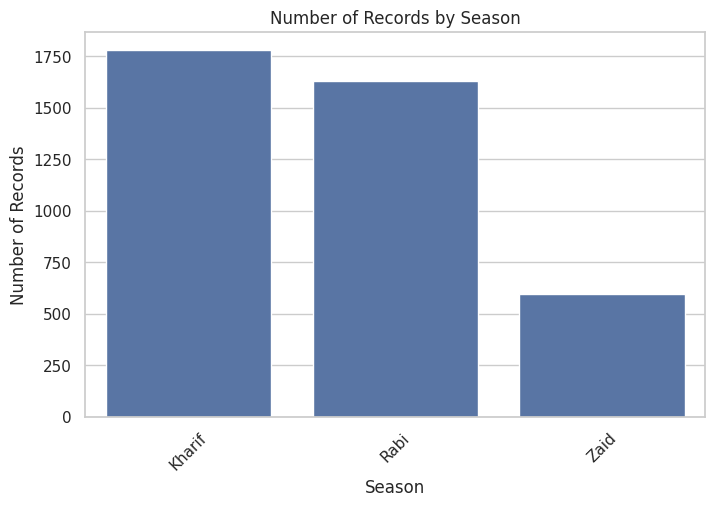

In [20]:
print(df_clean['Season'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='Season')

plt.title('Number of Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.show()

## 17. Yield Performance Across Seasons

I am comparing yield across seasons using the mean, median, standard deviation, minimum and maximum values.

In [21]:
season_yield = df_yield.groupby('Season')['Yield_Tonnes_Ha'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).round(2)

season_yield

,count,mean,median,std,min,max
Season,,,,,,
Kharif,1772,5.64,1.95,14.42,0.3,101.44
Rabi,1607,5.08,1.66,12.83,0.3,93.13
Zaid,589,4.67,1.45,11.32,0.3,64.76


## 18. Average Yield by Season

This graph provides a visual comparison of average yield between seasons.

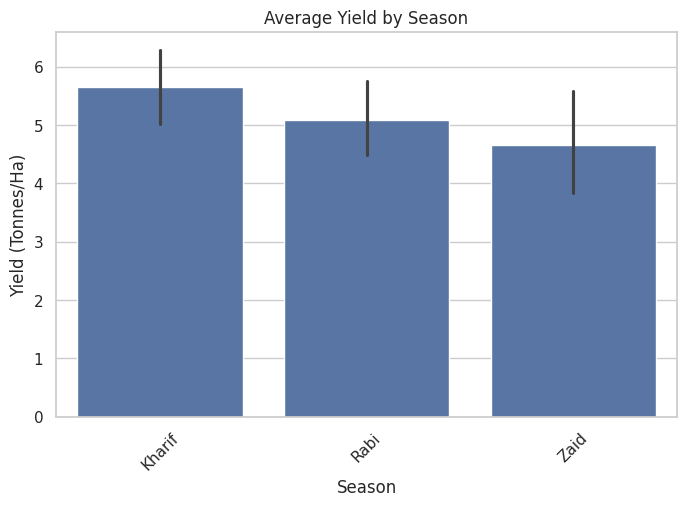

In [22]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_yield,
    x='Season',
    y='Yield_Tonnes_Ha',
    estimator='mean'
)

plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.show()

## 19. Yield Variation Across Seasons

I am using a boxplot to compare the distribution and variation of yield across seasons.

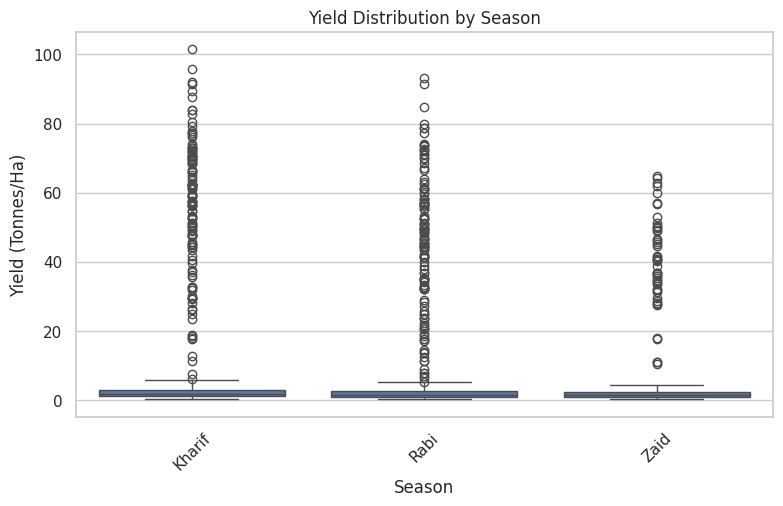

In [23]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_yield,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title('Yield Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.show()

## 20. Environmental Conditions Across Seasons

Environmental conditions can influence agricultural performance. I am comparing rainfall, temperature, humidity, sunlight and soil moisture across seasons.

In [24]:
environmental_summary = df_clean.groupby('Season')[
    [
        'Rainfall_mm',
        'Avg_Temperature_C',
        'Humidity_pct',
        'Sunlight_Hours_Day',
        'Soil_Moisture_pct'
    ]
].mean().round(2)

environmental_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.10,28.45,71.81,6.79,31.20
Rabi,435.95,23.49,57.89,7.59,24.05
Zaid,299.16,31.04,52.01,8.18,19.18


## 21. Environmental Comparison

The following chart compares the average environmental conditions across seasons.

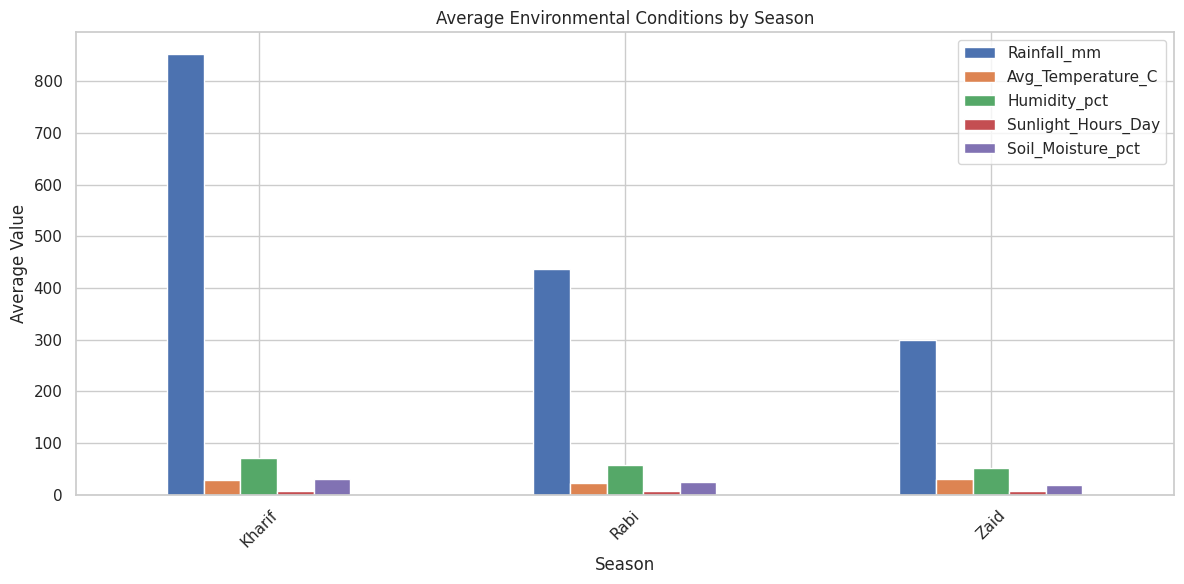

In [25]:
environmental_summary.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Average Environmental Conditions by Season')
plt.xlabel('Season')
plt.ylabel('Average Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 22. Resource Usage Across Seasons

I am comparing water, fertilizer, pesticide and nutrient usage across seasons.

In [26]:
resource_summary = df_clean.groupby('Season')[
    [
        'Water_Used_m3',
        'Fertilizer_kg_ha',
        'Pesticide_Litre_ha',
        'Nitrogen_kg_ha',
        'Phosphorus_kg_ha',
        'Potassium_kg_ha'
    ]
].mean().round(2)

resource_summary

,Water_Used_m3,Fertilizer_kg_ha,Pesticide_Litre_ha,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha
Season,,,,,,
Kharif,6102.20,187.08,5.08,120.02,58.10,105.30
Rabi,5846.99,185.41,5.02,120.40,57.31,103.93
Zaid,6419.89,184.64,5.17,120.53,58.13,105.42


## 23. Irrigation Method Analysis

I am comparing irrigation methods based on average yield, water usage and profit.

In [27]:
irrigation_summary = df_clean.groupby('Irrigation_Method').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Water=('Water_Used_m3', 'mean'),
    Average_Profit=('Profit_INR', 'mean')
).round(2)

irrigation_summary.sort_values(
    'Average_Yield',
    ascending=False
)

,Average_Yield,Average_Water,Average_Profit
Irrigation_Method,,,
Drip,6.62,5918.75,219626.00
Sprinkler,5.19,6208.26,91121.08
Flood,4.90,8026.47,73354.02
Rainfed,4.61,3549.55,79050.37


## 24. Crop-wise Performance

I am comparing different crops based on average yield, production, revenue and profit.

In [28]:
crop_summary = df_clean.groupby('Crop').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Production=('Production_Tonnes', 'mean'),
    Average_Revenue=('Revenue_INR', 'mean'),
    Average_Profit=('Profit_INR', 'mean')
).round(2)

crop_summary.sort_values('Average_Yield', ascending=False)

,Average_Yield,Average_Production,Average_Revenue,Average_Profit
Crop,,,,
Sugarcane,46.94,392.41,1371980.11,817187.99
Maize,2.72,21.78,457067.99,-83978.33
Rice,2.44,19.29,423615.26,-102213.50
Wheat,2.11,16.85,400104.89,-123398.34
Chilli,1.54,12.38,1276777.23,750878.34
Groundnut,1.32,9.66,542935.50,44858.12
Cotton,1.23,9.40,639423.08,124546.92
Pulses,0.92,7.40,528465.87,-4238.05


## 25. Average Yield by Crop

This graph compares the average yield of the different crops in the dataset.

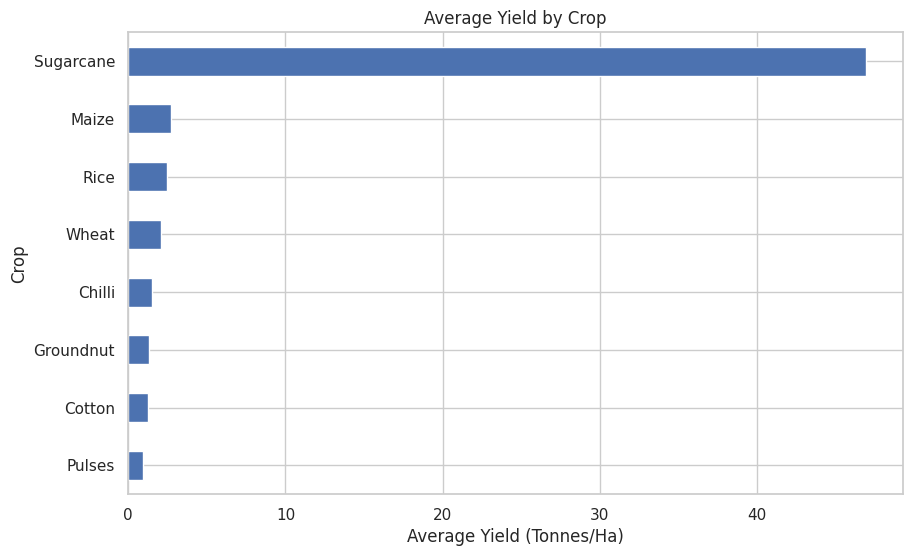

In [29]:
crop_yield = df_yield.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values()

plt.figure(figsize=(10, 6))

crop_yield.plot(kind='barh')

plt.title('Average Yield by Crop')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('Crop')
plt.show()

## 26. Crop Performance Across Seasons

I am comparing the average yield of each crop across different seasons.

In [30]:
crop_season = df_yield.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
).round(2)

crop_season

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.61,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.94,38.42
Wheat,2.26,2.06,1.75


## 27. Crop and Season Heatmap

The heatmap makes it easier to compare crop yield across seasons.

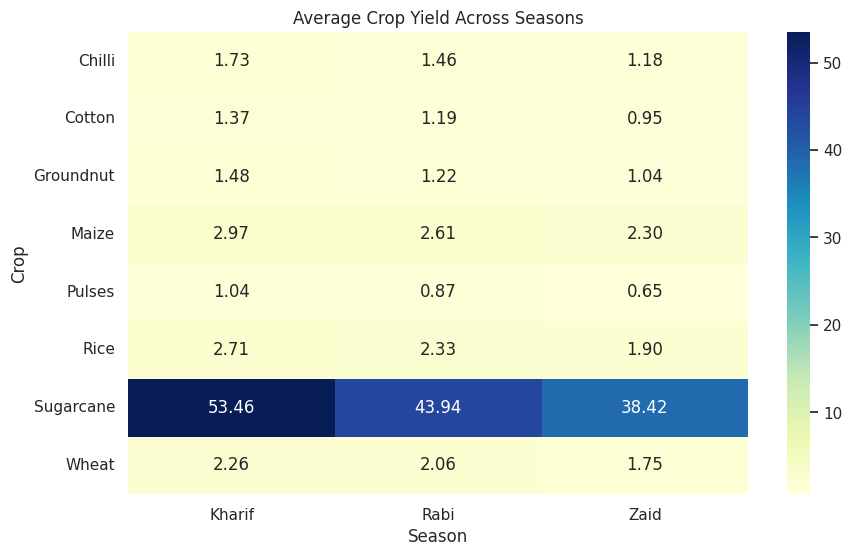

In [32]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    crop_season,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.show()

## 28. State-wise Agricultural Performance

I am comparing agricultural performance across states using average yield, production and profit.

In [33]:
state_summary = df_clean.groupby('State').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Production=('Production_Tonnes', 'mean'),
    Average_Profit=('Profit_INR', 'mean')
).round(2)

state_summary.sort_values('Average_Yield', ascending=False)

,Average_Yield,Average_Production,Average_Profit
State,,,
Punjab,6.12,52.23,136025.64
Karnataka,5.73,47.73,119422.34
Gujarat,5.70,48.33,117568.24
Telangana,5.08,39.25,108829.62
Maharashtra,5.03,43.98,135428.86
Madhya Pradesh,5.03,37.56,86840.76
Tamil Nadu,4.90,40.84,117744.75
Andhra Pradesh,4.65,36.91,73453.53


## 29. Economic Performance Across Seasons

Agricultural performance also includes financial outcomes. I am comparing market price, cost, revenue and profit across seasons.

In [34]:
economic_summary = df_clean.groupby('Season').agg(
    Average_Market_Price=('Market_Price_INR_Tonne', 'mean'),
    Average_Cost=('Total_Cost_INR', 'mean'),
    Average_Revenue=('Revenue_INR', 'mean'),
    Average_Profit=('Profit_INR', 'mean')
).round(2)

economic_summary

,Average_Market_Price,Average_Cost,Average_Revenue,Average_Profit
Season,,,,
Kharif,44850.91,531804.41,710719.06,178914.65
Rabi,44747.97,513836.58,601526.05,87689.47
Zaid,44212.03,543976.73,519171.90,-24804.82


## 30. Average Profit by Season

This graph compares the average profit generated across seasons.

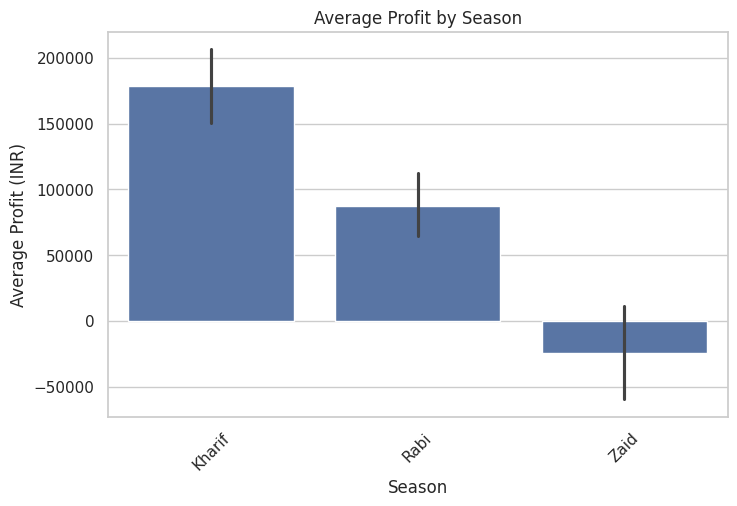

In [35]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Profit_INR',
    estimator='mean'
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.show()

## 31. Environmental Factors and Yield

I am checking the correlation between environmental conditions and yield.

Correlation shows the strength and direction of a linear relationship. It does not by itself prove causation.

In [36]:
environmental_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_Moisture_pct'
]

environmental_correlation = df_yield[
    environmental_columns + ['Yield_Tonnes_Ha']
].corr()['Yield_Tonnes_Ha'].sort_values(ascending=False)

environmental_correlation

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Rainfall_mm,0.028166
Humidity_pct,0.011277
Soil_Moisture_pct,0.009989
Avg_Temperature_C,0.009349
Sunlight_Hours_Day,-0.015362


## 32. Resource Factors and Yield

I am checking the relationship between resource usage and yield.

In [37]:
resource_columns = [
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Water_Used_m3',
    'Seed_Quality_Score'
]

resource_correlation = df_yield[
    resource_columns + ['Yield_Tonnes_Ha']
].corr()['Yield_Tonnes_Ha'].sort_values(ascending=False)

resource_correlation

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Used_m3,0.388653
Nitrogen_kg_ha,0.053867
Phosphorus_kg_ha,0.047821
Potassium_kg_ha,0.003836
Fertilizer_kg_ha,0.000562
Seed_Quality_Score,-0.006737
Pesticide_Litre_ha,-0.007650


## 33. Correlation Heatmap

I am using a correlation heatmap to view relationships between major agricultural variables.

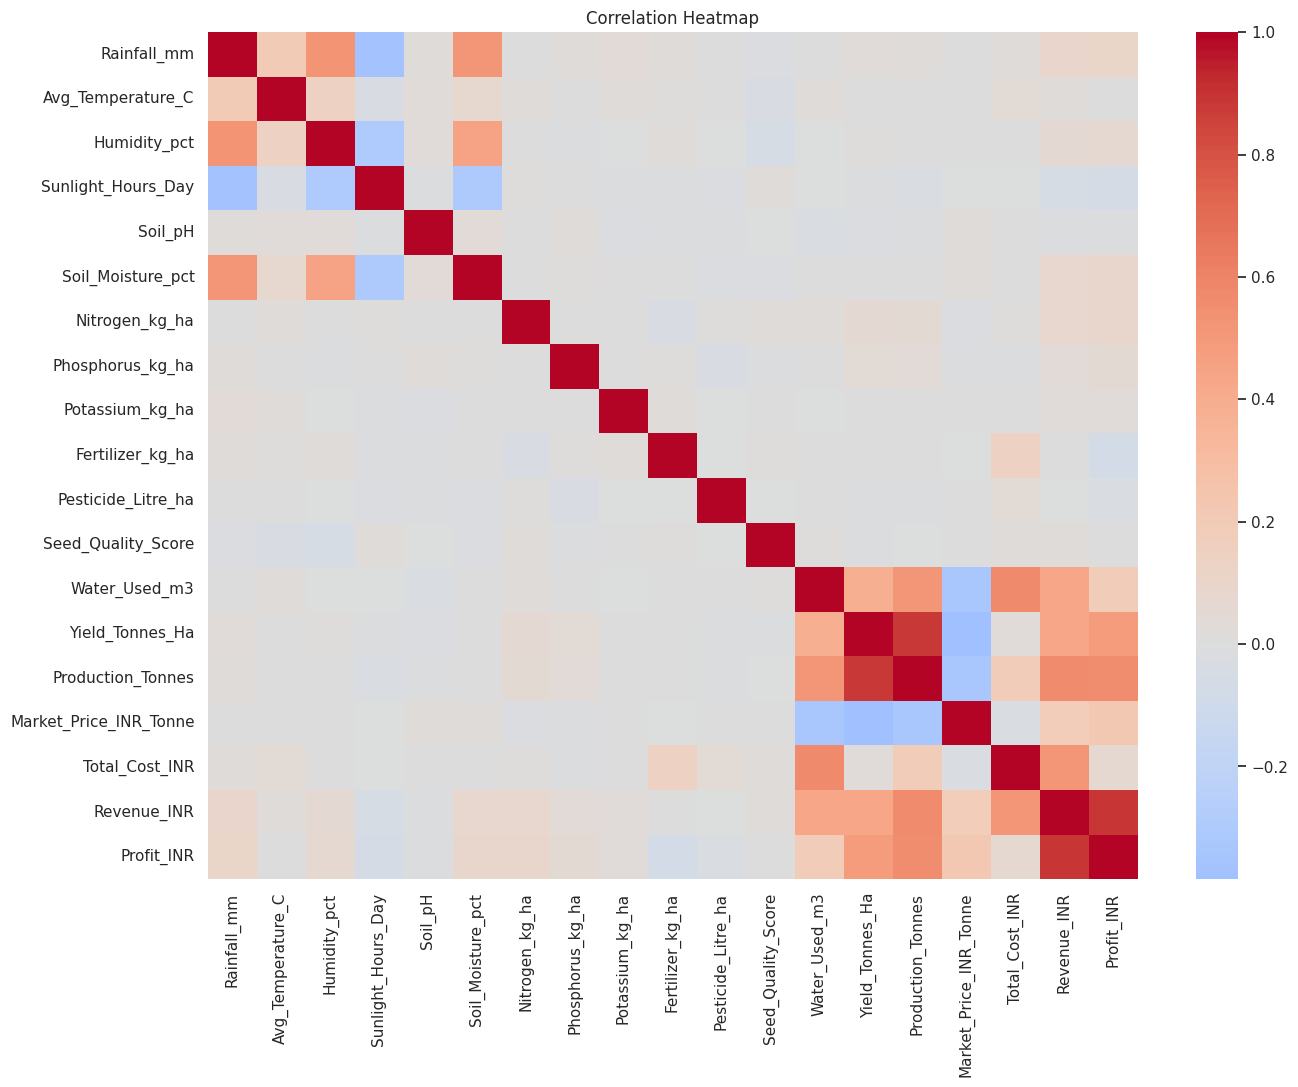

In [38]:
correlation_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Water_Used_m3',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR'
]

corr = df_yield[correlation_columns].corr()

plt.figure(figsize=(15, 11))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap')
plt.show()

## 34. Rainfall and Yield

I am using a scatter plot to examine the relationship between rainfall and yield.

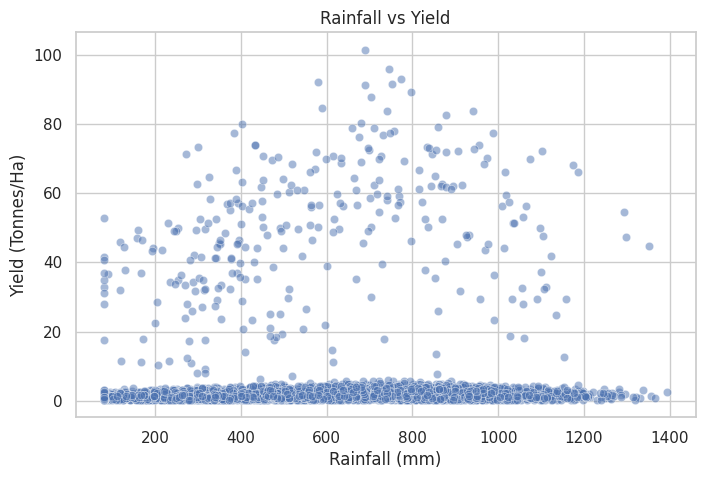

In [39]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_yield,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    alpha=0.5
)

plt.title('Rainfall vs Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

## 35. Soil Moisture and Yield

I am checking the relationship between soil moisture and yield.

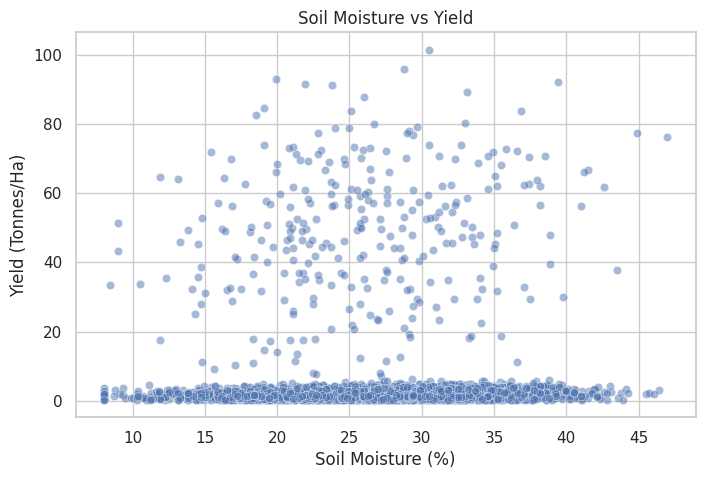

In [40]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_yield,
    x='Soil_Moisture_pct',
    y='Yield_Tonnes_Ha',
    alpha=0.5
)

plt.title('Soil Moisture vs Yield')
plt.xlabel('Soil Moisture (%)')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

## 36. Disease and Pest Risk

I am comparing disease and pest risk across different seasons.

In [41]:
risk_summary = df_clean.groupby('Season')['Disease_Pest_Risk_pct'].agg(
    ['mean', 'median', 'min', 'max']
).round(2)

risk_summary

,mean,median,min,max
Season,,,,
Kharif,54.47,54.5,21.3,88.9
Rabi,40.48,40.6,5.1,71.2
Zaid,38.22,37.9,5.0,71.6


## 37. Disease and Pest Risk by Season

This graph compares the average disease and pest risk across seasons.

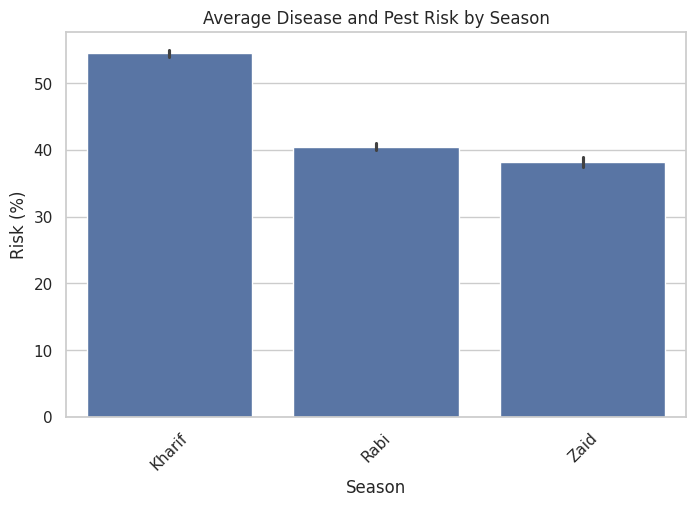

In [42]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Disease_Pest_Risk_pct',
    estimator='mean'
)

plt.title('Average Disease and Pest Risk by Season')
plt.xlabel('Season')
plt.ylabel('Risk (%)')
plt.xticks(rotation=45)
plt.show()

## 38. Outlier Analysis

I am using boxplots to identify unusually high or low values in important numerical variables.

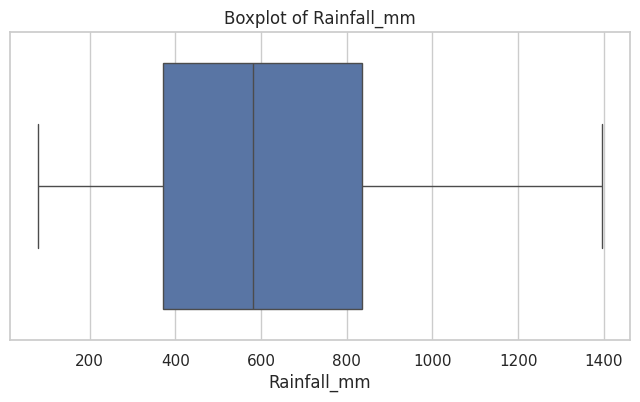

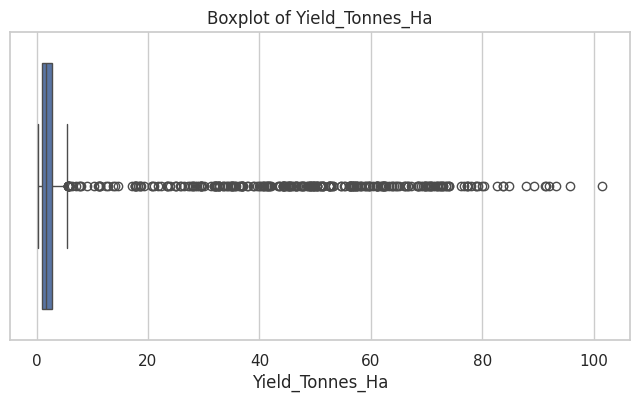

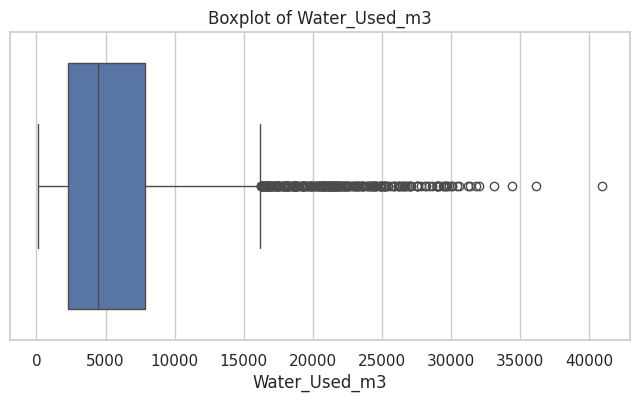

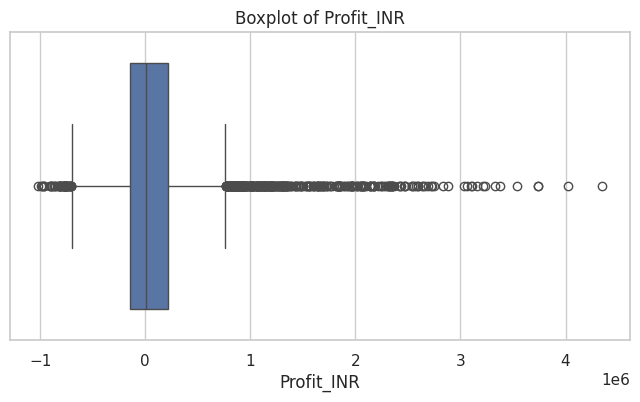

In [43]:
for column in [
    'Rainfall_mm',
    'Yield_Tonnes_Ha',
    'Water_Used_m3',
    'Profit_INR'
]:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df_clean[column].dropna())

    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()

## 39. Statistical Test: Kruskal-Wallis Test

The Kruskal-Wallis test is used to check whether there is a statistically significant difference in yield distribution across the seasons.

H0: There is no significant difference in yield distribution between seasons.

H1: At least one season has a different yield distribution.

A p-value below 0.05 is considered statistically significant in this analysis.

In [44]:
season_groups = [
    group['Yield_Tonnes_Ha'].dropna()
    for _, group in df_clean.groupby('Season')
]

statistic, p_value = kruskal(*season_groups)

print("Kruskal-Wallis Statistic:", round(statistic, 4))
print("p-value:", round(p_value, 6))

if p_value < 0.05:
    print("Result: There is a statistically significant difference in yield between seasons.")
else:
    print("Result: No statistically significant difference in yield between seasons was found.")

Kruskal-Wallis Statistic: 68.6043
p-value: 0.0
Result: There is a statistically significant difference in yield between seasons.


## 40. Key Findings

The following observations are generated directly from the dataset so that the findings are based on the actual analysis results.

In [45]:
best_yield_season = season_yield['mean'].idxmax()
best_yield_value = season_yield['mean'].max()

lowest_yield_season = season_yield['mean'].idxmin()
lowest_yield_value = season_yield['mean'].min()

best_profit_season = season_profit = df_clean.groupby(
    'Season'
)['Profit_INR'].mean()

best_profit_season_name = best_profit_season.idxmax()
best_profit_value = best_profit_season.max()

best_crop = crop_summary['Average_Yield'].idxmax()
best_crop_yield = crop_summary['Average_Yield'].max()

best_state = state_summary['Average_Yield'].idxmax()
best_state_yield = state_summary['Average_Yield'].max()

print("Key Findings")
print("-" * 50)

print(
    f"Highest average yield: {best_yield_season} "
    f"({best_yield_value:.2f} tonnes/ha)"
)

print(
    f"Lowest average yield: {lowest_yield_season} "
    f"({lowest_yield_value:.2f} tonnes/ha)"
)

print(
    f"Highest average profit: {best_profit_season_name} "
    f"(INR {best_profit_value:,.2f})"
)

print(
    f"Highest average-yield crop: {best_crop} "
    f"({best_crop_yield:.2f} tonnes/ha)"
)

print(
    f"Highest average-yield state: {best_state} "
    f"({best_state_yield:.2f} tonnes/ha)"
)

if p_value < 0.05:
    print("Seasonal yield difference is statistically significant.")
else:
    print("Seasonal yield difference is not statistically significant.")

Key Findings
--------------------------------------------------
Highest average yield: Kharif (5.64 tonnes/ha)
Lowest average yield: Zaid (4.67 tonnes/ha)
Highest average profit: Kharif (INR 178,914.65)
Highest average-yield crop: Sugarcane (46.94 tonnes/ha)
Highest average-yield state: Punjab (6.12 tonnes/ha)
Seasonal yield difference is statistically significant.


## 41. Recommendations

Based on the analysis, the following recommendations can be considered:

- Seasonal agricultural planning should consider differences in yield and environmental conditions.
- Water usage should be monitored along with agricultural output.
- Crop selection can be planned according to crop performance across seasons.
- Rainfall and soil moisture should be monitored during seasonal planning.
- Irrigation methods can be compared using water usage, yield and profit.
- Economic factors such as cost, revenue and profit should be considered along with production.
- Unusual observations and high-risk conditions should be investigated further before making important decisions.

## 42. Conclusion

This project analyzed the Seasonal Agriculture Performance dataset using Python.

The analysis included data cleaning, seasonal yield comparison, crop performance, state-wise comparison, environmental conditions, resource usage, irrigation methods, economic performance, disease and pest risk, correlation analysis, outlier analysis and statistical testing.

The results help in understanding how agricultural performance varies across seasons and how environmental, resource and economic factors are related to agricultural outcomes.

The analysis provides a data-based understanding of seasonal agricultural performance and can support better seasonal agricultural planning.

## 43. Project Summary

The project followed these major steps:

1. Dataset loading and exploration
2. Missing value and duplicate analysis
3. Data cleaning and preparation
4. Seasonal performance analysis
5. Environmental condition analysis
6. Resource and irrigation analysis
7. Crop and state comparison
8. Economic performance analysis
9. Relationship and correlation analysis
10. Disease and pest risk analysis
11. Outlier analysis
12. Statistical testing
13. Findings and recommendations
14. Final conclusion

The analysis was performed using Python, Pandas, NumPy, Matplotlib, Seaborn and SciPy.

## 44. Key Questions and Answers

The key questions given in the project requirements are answered below based on the analysis performed on the dataset.


### Question 1: How does agricultural performance vary across different seasons?

**Answer:**
Agricultural performance varies across seasons. Based on the analysis, Kharif recorded the highest average yield of 5.64 tonnes/ha, while Zaid recorded the lowest average yield of 4.67 tonnes/ha. The statistical test also showed that the difference in yield between seasons is statistically significant.


### Question 2: What are the major seasonal patterns in agricultural performance?

**Answer:**
The analysis shows seasonal differences in yield, environmental conditions, resource usage and economic performance. These differences indicate that agricultural performance is not the same across all seasons.


### Question 3: Which characteristics change significantly between seasons?

**Answer:**
Rainfall, temperature, humidity, soil moisture, resource usage and yield show variations between seasons. These characteristics were compared using seasonal summaries and visualizations to understand the differences.


### Question 4: How do agricultural activities differ across seasons?

**Answer:**
Agricultural activities differ across seasons in terms of crop production, irrigation, fertilizer usage, pesticide usage and water consumption. The analysis shows that farming requirements change according to seasonal conditions.


### Question 5: How does resource usage vary across seasons?

**Answer:**
Resource usage varies across seasons. Water, fertilizer, pesticide and nutrient usage were compared to understand the differences in agricultural resource requirements between seasons.


### Question 6: How are environmental conditions related to agricultural outcomes?

**Answer:**
Environmental conditions such as rainfall, temperature, humidity and soil moisture were compared with agricultural outcomes. Correlation analysis was used to examine the relationships between these variables and yield.


### Question 7: How do economic outcomes differ across seasons?

**Answer:**
Economic performance differs across seasons because market price, cost, revenue and profit vary between seasons. Based on the analysis, Kharif recorded the highest average profit of approximately ₹178,914.65.


### Question 8: Are agricultural performance patterns consistent across regions and categories?

**Answer:**
Agricultural performance varies across regions and crop categories. The crop-wise and state-wise analysis shows differences in average yield and other performance indicators. Punjab recorded the highest average yield among the states at 6.12 tonnes/ha.


### Question 9: Are there any unusual patterns or significant variations in the data?

**Answer:**
The dataset contains variations in several agricultural indicators. Outlier analysis was performed to identify observations that differ from the general distribution, while the Kruskal-Wallis test was used to check for significant differences in yield between seasons.


### Question 10: What insights can be gained from seasonal differences?

**Answer:**
The seasonal analysis provides useful insights into crop productivity, environmental conditions, resource usage and economic performance. Kharif showed the highest average yield and average profit among the seasons analyzed.


### Question 11: What conclusions can be drawn to support better seasonal agricultural planning?

**Answer:**
The analysis suggests that seasonal planning should consider crop performance, environmental conditions, resource requirements and economic outcomes. Comparing these factors across seasons can help in making better decisions about crop selection and resource management.
